# Heart Disease Prediction: Binary Classification

**Dataset:** UCI Cleveland Heart Disease — 303 patients, 13 clinical features (age, sex, chest pain type, resting BP, cholesterol, max heart rate, ST depression, etc.).

**Target:** Binary — presence (1) or absence (0) of heart disease.

**Objective:** Compare Logistic Regression and Random Forest classifiers with sklearn Pipelines, evaluate with confusion matrices and ROC curves, and tune the best model with GridSearchCV.

---

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay, accuracy_score, roc_auc_score

## 1. Dataset & Preprocessing

In [7]:
# Column names from UCI description
col_names = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]

# Load the processed Cleveland data (comma-separated, no header)
df = pd.read_csv("heart_disease.csv", header=None, names=col_names)

print("Shape:", df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [8]:
# Basic info / summary
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 1.1 Data Cleaning

Replace `?` missing values in `ca` and `thal` with NaN, impute with mode. Convert multi-class target (0–4) to binary: 0 = no disease, 1 = disease present.

In [12]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Columns with missing values
print(df.isna().sum())

# Convert ca & thal to numeric
df["ca"] = pd.to_numeric(df["ca"], errors="coerce")
df["thal"] = pd.to_numeric(df["thal"], errors="coerce")

print("\nMissing after numeric conversion:")
print(df.isna().sum())

# Impute missing values in ca & thal with most frequent (mode)
imputer = SimpleImputer(strategy="most_frequent")
df[["ca", "thal"]] = imputer.fit_transform(df[["ca", "thal"]])

print("\nMissing after imputation:")
print(df.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing after numeric conversion:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [13]:
# Convert target to binary: 0 = no disease, 1 = disease
df["target"] = (df["target"] > 0).astype(int)

df["target"].value_counts()

,count
target,
0,164
1,139


## 2. Exploratory Data Analysis

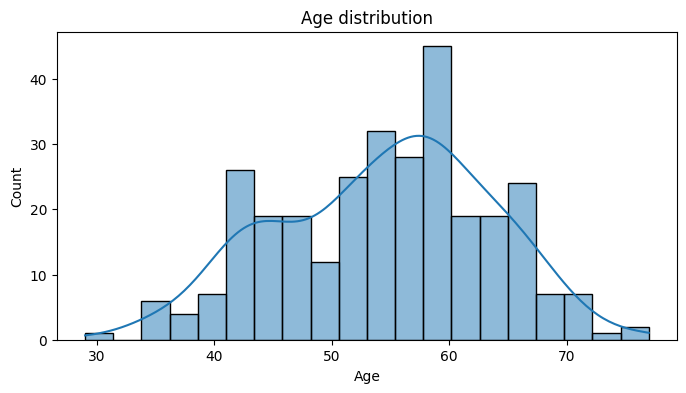

In [14]:
# 1) Distribution of age
plt.figure(figsize=(8,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

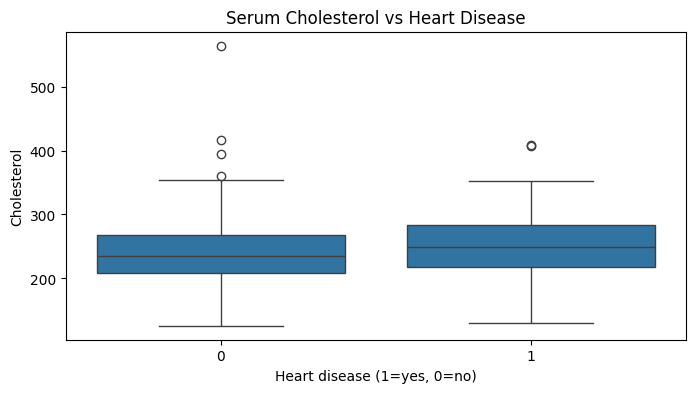

In [15]:
# 2) Cholesterol by target (boxplot)
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="target", y="chol")
plt.title("Serum Cholesterol vs Heart Disease")
plt.xlabel("Heart disease (1=yes, 0=no)")
plt.ylabel("Cholesterol")
plt.show()

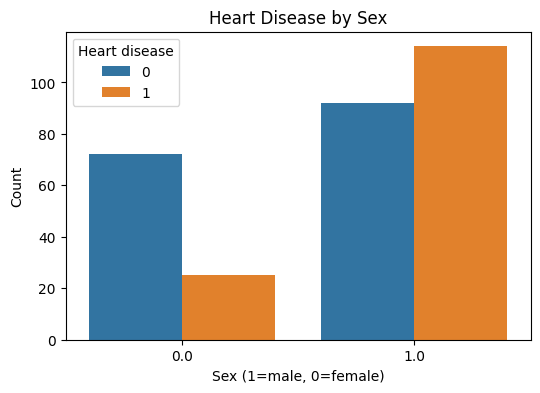

In [16]:
# 3) Count of heart disease by sex
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="target")
plt.title("Heart Disease by Sex")
plt.xlabel("Sex (1=male, 0=female)")
plt.ylabel("Count")
plt.legend(title="Heart disease")
plt.show()

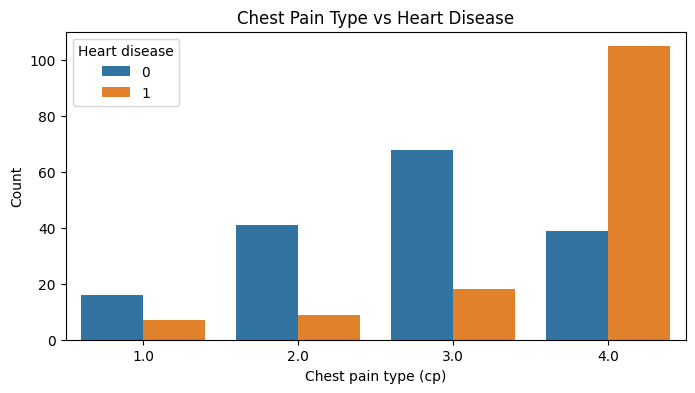

In [17]:
# 4) Chest pain type vs target
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="cp", hue="target")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest pain type (cp)")
plt.ylabel("Count")
plt.legend(title="Heart disease")
plt.show()

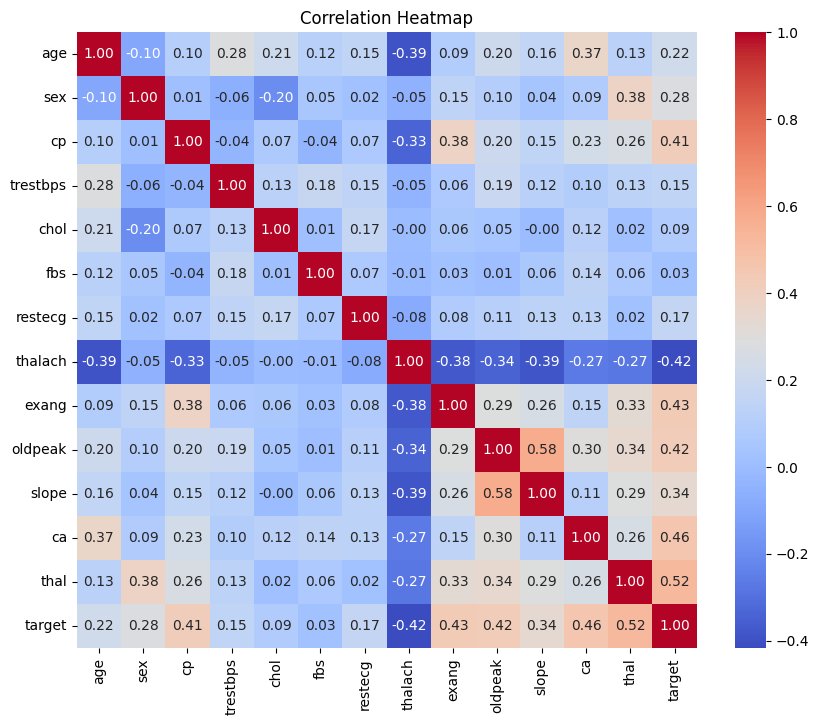

In [18]:
# 5) Correlation heatmap for numeric features
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

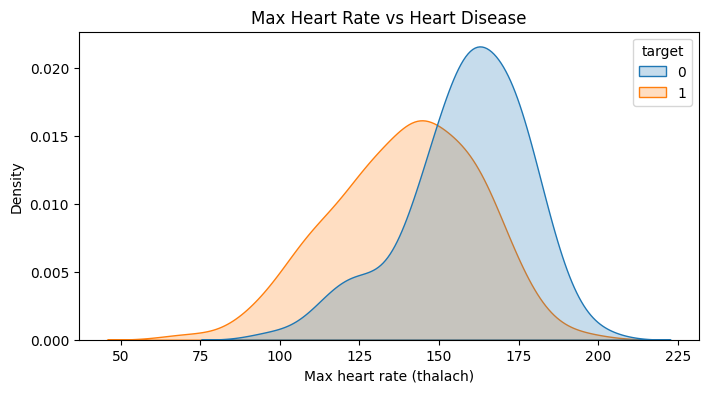

In [19]:
# 6) Thalach (max heart rate) distribution by target
plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x="thalach", hue="target", fill=True, common_norm=False)
plt.title("Max Heart Rate vs Heart Disease")
plt.xlabel("Max heart rate (thalach)")
plt.show()

## 3. Modelling Pipeline

Sklearn `Pipeline` with `ColumnTransformer`: StandardScaler for numeric features, OneHotEncoder for categorical. Stratified 80/20 train/test split.

In [20]:
X = df.drop("target", axis=1)
y = df["target"]

numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(242, 13) (61, 13)


### 3.1 Logistic Regression

In [24]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification report:\n", classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.8852459016393442
ROC-AUC: 0.9664502164502166

Confusion matrix:
 [[28  5]
 [ 2 26]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



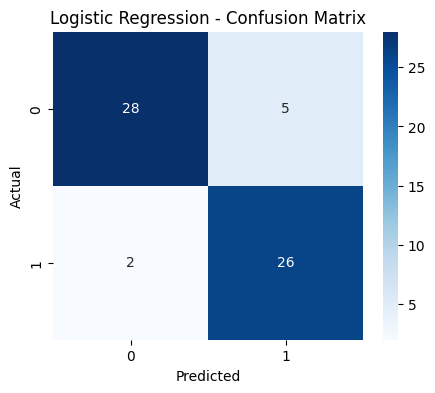

In [25]:
# Confusion matrix heatmap for LR
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

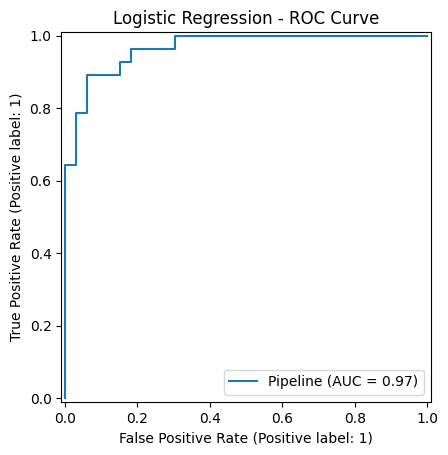

In [26]:
# ROC curve for LR
RocCurveDisplay.from_estimator(log_reg_pipeline, X_test, y_test)
plt.title("Logistic Regression - ROC Curve")
plt.show()

### 3.2 Random Forest

In [27]:
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.8688524590163934
ROC-AUC: 0.9426406926406926

Confusion matrix:
 [[27  6]
 [ 2 26]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



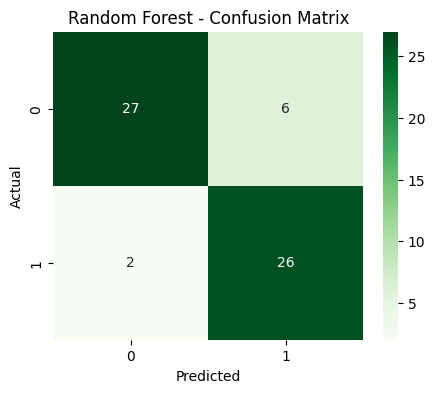

In [28]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

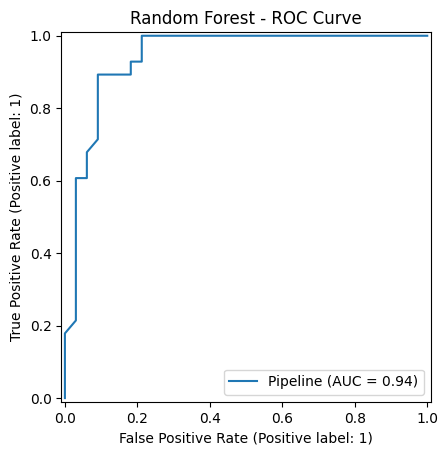

In [29]:
# ROC curve for RF
RocCurveDisplay.from_estimator(rf_pipeline, X_test, y_test)
plt.title("Random Forest - ROC Curve")
plt.show()

### 3.3 Hyperparameter Tuning (GridSearchCV)

In [30]:
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 4],
    "model__min_samples_leaf": [1, 2]
}

rf_base = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 50}
Best CV accuracy: 0.8097789115646258


In [31]:
# Evaluate best RF on test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("=== Tuned Random Forest ===")
print("Test accuracy:", accuracy_score(y_test, y_pred_best))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_best))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification report:\n", classification_report(y_test, y_pred_best))

=== Tuned Random Forest ===
Test accuracy: 0.9016393442622951
Test ROC-AUC: 0.9480519480519481

Confusion matrix:
 [[29  4]
 [ 2 26]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



## Conclusions

| Model                  | Accuracy | ROC-AUC  | Notes                                              |
|:-----------------------|:---------|:---------|:---------------------------------------------------|
| Logistic Regression    | 0.885    | 0.966    | Strong baseline; highly interpretable              |
| Random Forest (Untuned)| 0.869    | 0.943    | Better captures non-linear feature interactions    |
| Tuned Random Forest    | 0.902    | 0.948    | GridSearchCV improved generalisation, highest accuracy |

**Key findings:**
- The **Tuned Random Forest** model achieved the highest accuracy on the test set (0.902), outperforming both the untuned Random Forest and Logistic Regression.
- **Logistic Regression** demonstrated a very high ROC-AUC score (0.966), indicating excellent discriminative power, even surpassing the tuned Random Forest in this metric.
- Max heart rate (`thalach`) and chest pain type (`cp`) are significant predictors of heart disease.
- Sex and ST depression (`oldpeak`) also show clear separation between classes.
- Both models benefited from the preprocessing pipeline; `StandardScaler` was particularly crucial for Logistic Regression convergence.
- The improvements from hyperparameter tuning with `GridSearchCV` were evident, leading to a better-performing Random Forest model.